# Impact of Higher Oil Prices on Cloud Vendor Margins
## Hyperscale vs. Neocloud: A Scenario Analysis

This analysis quantifies how rising oil prices flow through to electricity costs and ultimately compress operating margins for **hyperscale cloud vendors** (AWS, Azure, GCP) and **neocloud vendors** (CoreWeave, Lambda Labs, Nebius).

---

### Transmission Mechanism

```
Oil Price ↑ → Natural Gas Price ↑ → Electricity Price ↑ → Data Center OpEx ↑ → Margins ↓
```

- Natural gas fuels ~42% of U.S. electricity generation (EIA 2024)
- A permanent 20% oil price shock → ~16% increase in Henry Hub natural gas prices over one year (EIA)
- Electricity accounts for 40–60% of data center operating expenses
- Data centers consume ~4% of U.S. electricity (projected 6.7–12% by 2028)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

## 1. Oil Price Scenarios

We define five scenarios ranging from current baseline conditions to an extreme supply-shock scenario.

In [2]:
scenarios = pd.DataFrame({
    'Scenario': [
        'Baseline',
        'Moderate Rise',
        'Elevated',
        'Supply Shock',
        'Extreme Crisis'
    ],
    'Oil Price ($/bbl)': [70, 90, 110, 130, 150],
    'Oil Price Change (%)': [0, 28.6, 57.1, 85.7, 114.3],
    'Description': [
        'Current 2025-26 range (~$65-75 WTI)',
        'OPEC+ cuts, moderate demand growth',
        'Geopolitical tensions, supply constraints',
        'Regional conflict disrupting supply (e.g., Strait of Hormuz)',
        'Full-scale supply crisis (2008/2022 peak territory)'
    ]
})

# Oil → Natural Gas pass-through: ~0.8x (20% oil shock → 16% gas increase, per EIA)
OIL_TO_GAS_PASSTHROUGH = 0.80

# Natural Gas → Electricity pass-through: gas is 42% of generation mix,
# plus the marginal pricing effect (gas often sets the clearing price)
GAS_SHARE_OF_GENERATION = 0.42
MARGINAL_PRICING_MULTIPLIER = 1.35  # gas sets clearing price ~35% more often than its share
GAS_TO_ELECTRICITY_PASSTHROUGH = GAS_SHARE_OF_GENERATION * MARGINAL_PRICING_MULTIPLIER

scenarios['Nat Gas Price Change (%)'] = scenarios['Oil Price Change (%)'] * OIL_TO_GAS_PASSTHROUGH
scenarios['Electricity Price Change (%)'] = scenarios['Nat Gas Price Change (%)'] * GAS_TO_ELECTRICITY_PASSTHROUGH

scenarios_display = scenarios[['Scenario', 'Oil Price ($/bbl)', 'Oil Price Change (%)',
                                'Nat Gas Price Change (%)', 'Electricity Price Change (%)',
                                'Description']].copy()
scenarios_display['Oil Price Change (%)'] = scenarios_display['Oil Price Change (%)'].map('{:.1f}%'.format)
scenarios_display['Nat Gas Price Change (%)'] = scenarios_display['Nat Gas Price Change (%)'].map('{:.1f}%'.format)
scenarios_display['Electricity Price Change (%)'] = scenarios_display['Electricity Price Change (%)'].map('{:.1f}%'.format)

print("="*100)
print("OIL PRICE SCENARIOS & ENERGY COST TRANSMISSION")
print("="*100)
print(scenarios_display.to_string(index=False))
print("\nAssumptions:")
print(f"  Oil → Nat Gas pass-through: {OIL_TO_GAS_PASSTHROUGH:.0%}")
print(f"  Gas share of electricity gen: {GAS_SHARE_OF_GENERATION:.0%}")
print(f"  Marginal pricing multiplier: {MARGINAL_PRICING_MULTIPLIER:.2f}x")
print(f"  Effective Gas → Electricity pass-through: {GAS_TO_ELECTRICITY_PASSTHROUGH:.1%}")

OIL PRICE SCENARIOS & ENERGY COST TRANSMISSION
      Scenario  Oil Price ($/bbl) Oil Price Change (%) Nat Gas Price Change (%) Electricity Price Change (%)                                                  Description
      Baseline                 70                 0.0%                     0.0%                         0.0%                          Current 2025-26 range (~$65-75 WTI)
 Moderate Rise                 90                28.6%                    22.9%                        13.0%                           OPEC+ cuts, moderate demand growth
      Elevated                110                57.1%                    45.7%                        25.9%                    Geopolitical tensions, supply constraints
  Supply Shock                130                85.7%                    68.6%                        38.9% Regional conflict disrupting supply (e.g., Strait of Hormuz)
Extreme Crisis                150               114.3%                    91.4%                        

## 2. Vendor Cost Structures

### Hyperscale Vendors (AWS, Azure, GCP)
- Diversified revenue (IaaS, PaaS, SaaS, AI services)
- Operate at scale with long-term power purchase agreements (PPAs)
- Investing heavily in renewable energy and nuclear
- Energy: ~8-12% of total revenue (lower because of high-margin software/platform layers)

### Neocloud Vendors (CoreWeave, Lambda Labs, Nebius)
- GPU-as-a-Service, infrastructure-heavy model
- Higher power density per $ of revenue
- Less hedging, fewer long-term PPAs
- Energy: ~15-25% of total revenue

In [3]:
vendors = {
    # Hyperscale Vendors
    'AWS': {
        'type': 'Hyperscale',
        'revenue_B': 115.6,
        'operating_margin_pct': 39.4,  # $45.6B / $115.6B
        'energy_pct_of_cogs': 15.0,    # energy as % of total cost of revenue + opex
        'energy_pct_of_revenue': 9.1,  # energy as % of revenue
        'ppa_hedge_pct': 65,           # % of energy covered by long-term PPAs/renewables
        'color': '#FF9900'
    },
    'Azure': {
        'type': 'Hyperscale',
        'revenue_B': 109.4,
        'operating_margin_pct': 36.0,
        'energy_pct_of_cogs': 16.0,
        'energy_pct_of_revenue': 10.2,
        'ppa_hedge_pct': 60,
        'color': '#0078D4'
    },
    'GCP': {
        'type': 'Hyperscale',
        'revenue_B': 52.3,
        'operating_margin_pct': 14.0,
        'energy_pct_of_cogs': 14.0,
        'energy_pct_of_revenue': 12.0,
        'ppa_hedge_pct': 70,
        'color': '#4285F4'
    },
    # Neocloud Vendors
    'CoreWeave': {
        'type': 'Neocloud',
        'revenue_B': 3.1,  # ~$3.1B annualized from Q4 run-rate
        'operating_margin_pct': 6.0,
        'energy_pct_of_cogs': 25.0,
        'energy_pct_of_revenue': 23.5,
        'ppa_hedge_pct': 30,
        'color': '#00C853'
    },
    'Lambda Labs': {
        'type': 'Neocloud',
        'revenue_B': 0.8,
        'operating_margin_pct': 8.0,
        'energy_pct_of_cogs': 22.0,
        'energy_pct_of_revenue': 20.2,
        'ppa_hedge_pct': 20,
        'color': '#7C4DFF'
    },
    'Nebius': {
        'type': 'Neocloud',
        'revenue_B': 1.2,
        'operating_margin_pct': 5.0,
        'energy_pct_of_cogs': 24.0,
        'energy_pct_of_revenue': 22.8,
        'ppa_hedge_pct': 25,
        'color': '#E91E63'
    }
}

vendor_df = pd.DataFrame(vendors).T
vendor_df.index.name = 'Vendor'

print("="*95)
print("VENDOR BASELINE PROFILES")
print("="*95)
display_cols = ['type', 'revenue_B', 'operating_margin_pct', 'energy_pct_of_revenue', 'ppa_hedge_pct']
display_df = vendor_df[display_cols].copy()
display_df.columns = ['Type', 'Revenue ($B)', 'Op. Margin (%)', 'Energy/Revenue (%)', 'PPA Hedge (%)']
print(display_df.to_string())

VENDOR BASELINE PROFILES
                   Type Revenue ($B) Op. Margin (%) Energy/Revenue (%) PPA Hedge (%)
Vendor                                                                              
AWS          Hyperscale        115.6           39.4                9.1            65
Azure        Hyperscale        109.4           36.0               10.2            60
GCP          Hyperscale         52.3           14.0               12.0            70
CoreWeave      Neocloud          3.1            6.0               23.5            30
Lambda Labs    Neocloud          0.8            8.0               20.2            20
Nebius         Neocloud          1.2            5.0               22.8            25


## 3. Margin Impact Model

The margin impact is calculated as:

$$\Delta \text{Margin} = -\text{Energy}_{\%\text{rev}} \times \Delta\text{Electricity}_{\%} \times (1 - \text{Hedge}_{\%})$$

Where:
- **Energy % of Revenue**: How much of total revenue goes to electricity
- **Electricity Price Change**: Driven by oil → gas → power transmission
- **Hedge %**: Portion of energy costs locked via PPAs or renewables (insulated from spot price moves)

In [4]:
results = []

for _, scenario in scenarios.iterrows():
    elec_change = scenario['Electricity Price Change (%)'] / 100.0

    for vendor_name, v in vendors.items():
        energy_rev = v['energy_pct_of_revenue'] / 100.0
        hedge = v['ppa_hedge_pct'] / 100.0
        base_margin = v['operating_margin_pct']

        # Margin impact: increased energy cost as % of revenue, net of hedging
        margin_impact_pp = energy_rev * elec_change * (1 - hedge) * 100  # in percentage points
        new_margin = base_margin - margin_impact_pp

        # Dollar impact
        revenue = v['revenue_B']
        dollar_impact_B = (margin_impact_pp / 100.0) * revenue

        results.append({
            'Scenario': scenario['Scenario'],
            'Oil Price ($/bbl)': scenario['Oil Price ($/bbl)'],
            'Vendor': vendor_name,
            'Type': v['type'],
            'Baseline Margin (%)': base_margin,
            'Margin Impact (pp)': -margin_impact_pp,
            'New Margin (%)': new_margin,
            'Margin Change (%)': (new_margin - base_margin) / base_margin * 100 if base_margin != 0 else 0,
            'Profit Impact ($B)': -dollar_impact_B,
            'Color': v['color']
        })

results_df = pd.DataFrame(results)

print("="*120)
print("MARGIN IMPACT ACROSS ALL SCENARIOS AND VENDORS")
print("="*120)

pivot_margin = results_df.pivot_table(
    index=['Type', 'Vendor', 'Baseline Margin (%)'],
    columns='Scenario',
    values='New Margin (%)',
    aggfunc='first'
)[['Baseline', 'Moderate Rise', 'Elevated', 'Supply Shock', 'Extreme Crisis']]

print("\nOperating Margins (%) Under Each Scenario:")
print(pivot_margin.round(2).to_string())

print("\n")
pivot_impact = results_df.pivot_table(
    index=['Type', 'Vendor'],
    columns='Scenario',
    values='Margin Impact (pp)',
    aggfunc='first'
)[['Baseline', 'Moderate Rise', 'Elevated', 'Supply Shock', 'Extreme Crisis']]

print("Margin Impact (percentage points):")
print(pivot_impact.round(2).to_string())

MARGIN IMPACT ACROSS ALL SCENARIOS AND VENDORS

Operating Margins (%) Under Each Scenario:
Scenario                                    Baseline  Moderate Rise  Elevated  Supply Shock  Extreme Crisis
Type       Vendor      Baseline Margin (%)                                                                 
Hyperscale AWS         39.4                     39.4          38.99     38.58         38.16           37.75
           Azure       36.0                     36.0          35.47     34.94         34.41           33.88
           GCP         14.0                     14.0          13.53     13.07         12.60           12.13
Neocloud   CoreWeave   6.0                       6.0           3.87      1.74         -0.39           -2.53
           Lambda Labs 8.0                       8.0           5.90      3.81          1.72           -0.38
           Nebius      5.0                       5.0           2.78      0.57         -1.65           -3.87


Margin Impact (percentage points):
Scenario

In [5]:
# Detailed scenario-by-scenario summary tables
print("="*130)
print("DETAILED SCENARIO ANALYSIS")
print("="*130)

for _, scenario in scenarios.iterrows():
    sname = scenario['Scenario']
    oil_p = scenario['Oil Price ($/bbl)']
    elec_chg = scenario['Electricity Price Change (%)']

    print(f"\n{'─'*130}")
    print(f"  {sname.upper()} — Oil: ${oil_p}/bbl | Electricity Change: +{elec_chg:.1f}%")
    print(f"{'─'*130}")

    sc_df = results_df[results_df['Scenario'] == sname][[
        'Type', 'Vendor', 'Baseline Margin (%)', 'Margin Impact (pp)',
        'New Margin (%)', 'Margin Change (%)', 'Profit Impact ($B)'
    ]].copy()

    sc_df['Baseline Margin (%)'] = sc_df['Baseline Margin (%)'].map('{:.1f}%'.format)
    sc_df['Margin Impact (pp)'] = sc_df['Margin Impact (pp)'].map('{:+.2f} pp'.format)
    sc_df['New Margin (%)'] = sc_df['New Margin (%)'].map('{:.1f}%'.format)
    sc_df['Margin Change (%)'] = sc_df['Margin Change (%)'].map('{:+.1f}%'.format)
    sc_df['Profit Impact ($B)'] = sc_df['Profit Impact ($B)'].map('${:+.2f}B'.format)

    print(sc_df.to_string(index=False))

DETAILED SCENARIO ANALYSIS

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  BASELINE — Oil: $70/bbl | Electricity Change: +0.0%
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      Type      Vendor Baseline Margin (%) Margin Impact (pp) New Margin (%) Margin Change (%) Profit Impact ($B)
Hyperscale         AWS               39.4%           -0.00 pp          39.4%             +0.0%            $-0.00B
Hyperscale       Azure               36.0%           -0.00 pp          36.0%             +0.0%            $-0.00B
Hyperscale         GCP               14.0%           -0.00 pp          14.0%             +0.0%            $-0.00B
  Neocloud   CoreWeave                6.0%           -0.00 pp           6.0%             +0.0%            $-0.00B
  Neocloud Lambda Labs                8.0%           -0.00 pp           8.0%          

## 4. Visualizations

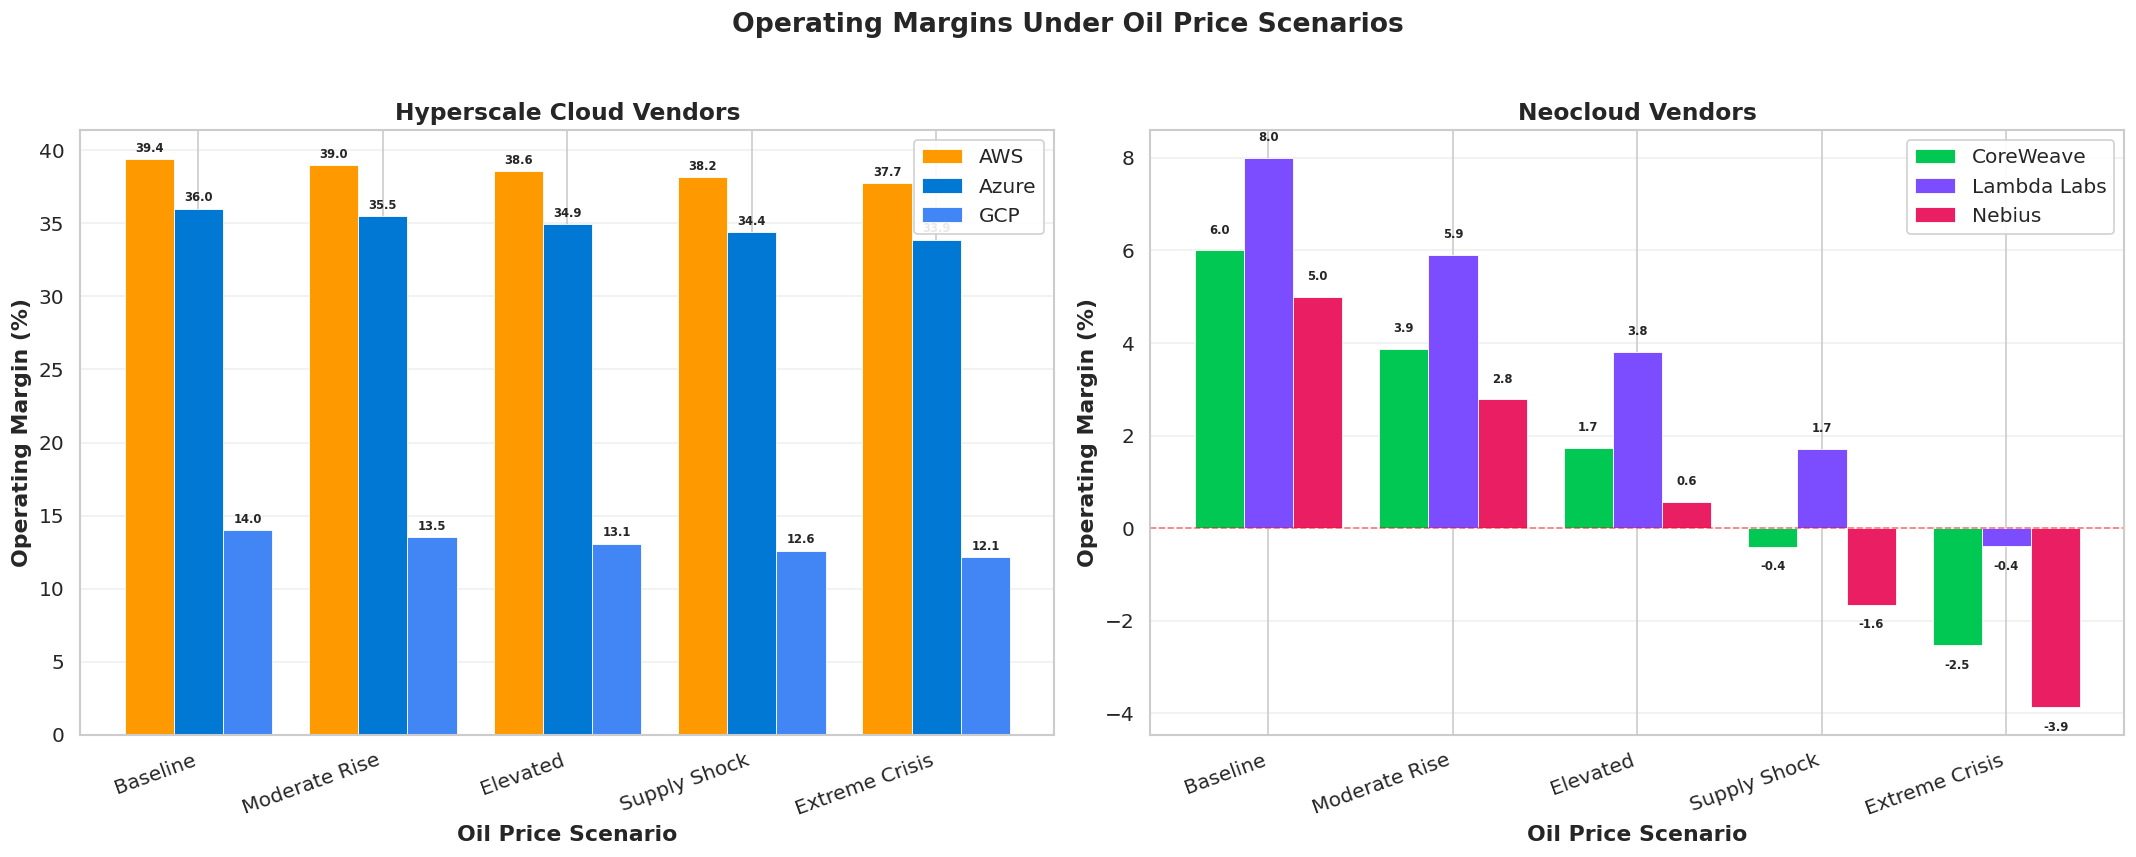

In [6]:
# Chart 1: Operating Margins Across Scenarios (Grouped Bar)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

scenario_names = ['Baseline', 'Moderate Rise', 'Elevated', 'Supply Shock', 'Extreme Crisis']

for ax, vtype, title in zip(axes, ['Hyperscale', 'Neocloud'],
                             ['Hyperscale Cloud Vendors', 'Neocloud Vendors']):
    type_df = results_df[results_df['Type'] == vtype]
    vendor_names = type_df['Vendor'].unique()
    n_vendors = len(vendor_names)
    x = np.arange(len(scenario_names))
    width = 0.8 / n_vendors

    for i, vendor in enumerate(vendor_names):
        vdata = type_df[type_df['Vendor'] == vendor]
        margins = [vdata[vdata['Scenario'] == s]['New Margin (%)'].values[0] for s in scenario_names]
        color = vendors[vendor]['color']
        bars = ax.bar(x + i * width - (n_vendors - 1) * width / 2, margins,
                      width, label=vendor, color=color, edgecolor='white', linewidth=0.5)

        for bar, margin in zip(bars, margins):
            va = 'bottom' if margin >= 0 else 'top'
            offset = 0.3 if margin >= 0 else -0.3
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                    f'{margin:.1f}', ha='center', va=va, fontsize=7, fontweight='bold')

    ax.set_xlabel('Oil Price Scenario', fontweight='bold')
    ax.set_ylabel('Operating Margin (%)', fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_names, rotation=20, ha='right')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Operating Margins Under Oil Price Scenarios', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_margins_by_scenario.png', bbox_inches='tight', dpi=150)
plt.show()

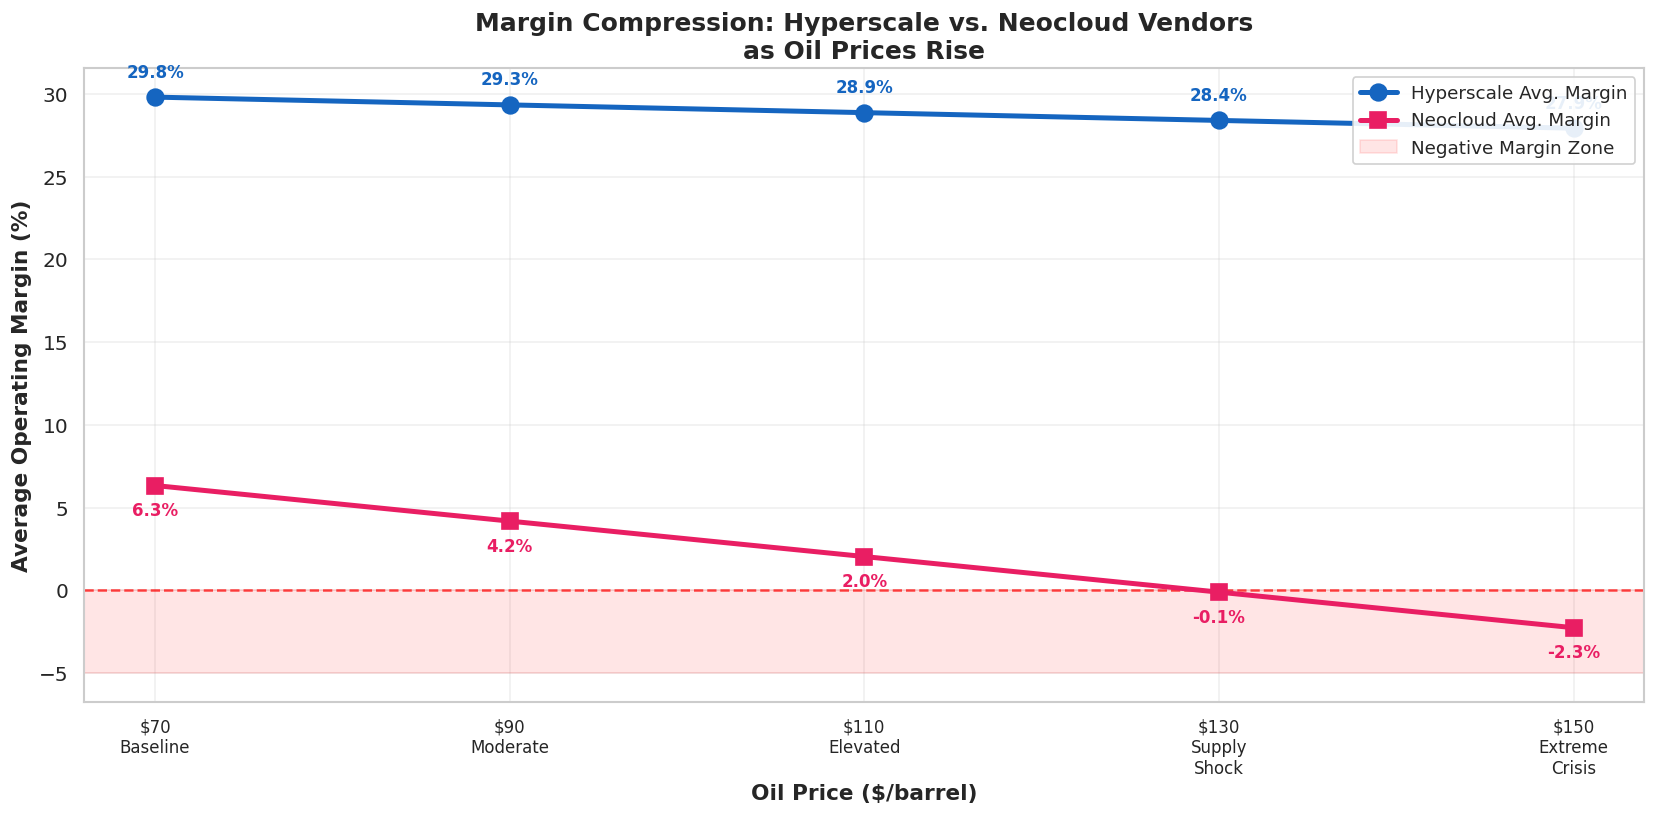

In [7]:
# Chart 2: Margin Erosion Waterfall (Hyperscale vs Neocloud averages)
fig, ax = plt.subplots(figsize=(14, 7))

hyper_avg = results_df[results_df['Type'] == 'Hyperscale'].groupby('Scenario').agg({
    'Baseline Margin (%)': 'mean',
    'New Margin (%)': 'mean',
    'Margin Impact (pp)': 'mean'
}).reindex(scenario_names)

neo_avg = results_df[results_df['Type'] == 'Neocloud'].groupby('Scenario').agg({
    'Baseline Margin (%)': 'mean',
    'New Margin (%)': 'mean',
    'Margin Impact (pp)': 'mean'
}).reindex(scenario_names)

oil_prices = [70, 90, 110, 130, 150]

ax.plot(oil_prices, hyper_avg['New Margin (%)'].values, 'o-', color='#1565C0',
        linewidth=3, markersize=10, label='Hyperscale Avg. Margin', zorder=5)
ax.plot(oil_prices, neo_avg['New Margin (%)'].values, 's-', color='#E91E63',
        linewidth=3, markersize=10, label='Neocloud Avg. Margin', zorder=5)

# Shade the neocloud danger zone
ax.axhspan(-5, 0, alpha=0.1, color='red', label='Negative Margin Zone')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

for i, (op, hm, nm) in enumerate(zip(oil_prices, hyper_avg['New Margin (%)'].values,
                                       neo_avg['New Margin (%)'].values)):
    ax.annotate(f'{hm:.1f}%', (op, hm), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold', color='#1565C0')
    ax.annotate(f'{nm:.1f}%', (op, nm), textcoords='offset points',
                xytext=(0, -18), ha='center', fontsize=10, fontweight='bold', color='#E91E63')

ax.set_xlabel('Oil Price ($/barrel)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Operating Margin (%)', fontsize=13, fontweight='bold')
ax.set_title('Margin Compression: Hyperscale vs. Neocloud Vendors\nas Oil Prices Rise',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.set_xticks(oil_prices)
ax.set_xticklabels([f'${p}\n{s}' for p, s in zip(oil_prices,
    ['Baseline', 'Moderate', 'Elevated', 'Supply\nShock', 'Extreme\nCrisis'])], fontsize=10)
ax.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_margin_compression.png', bbox_inches='tight', dpi=150)
plt.show()

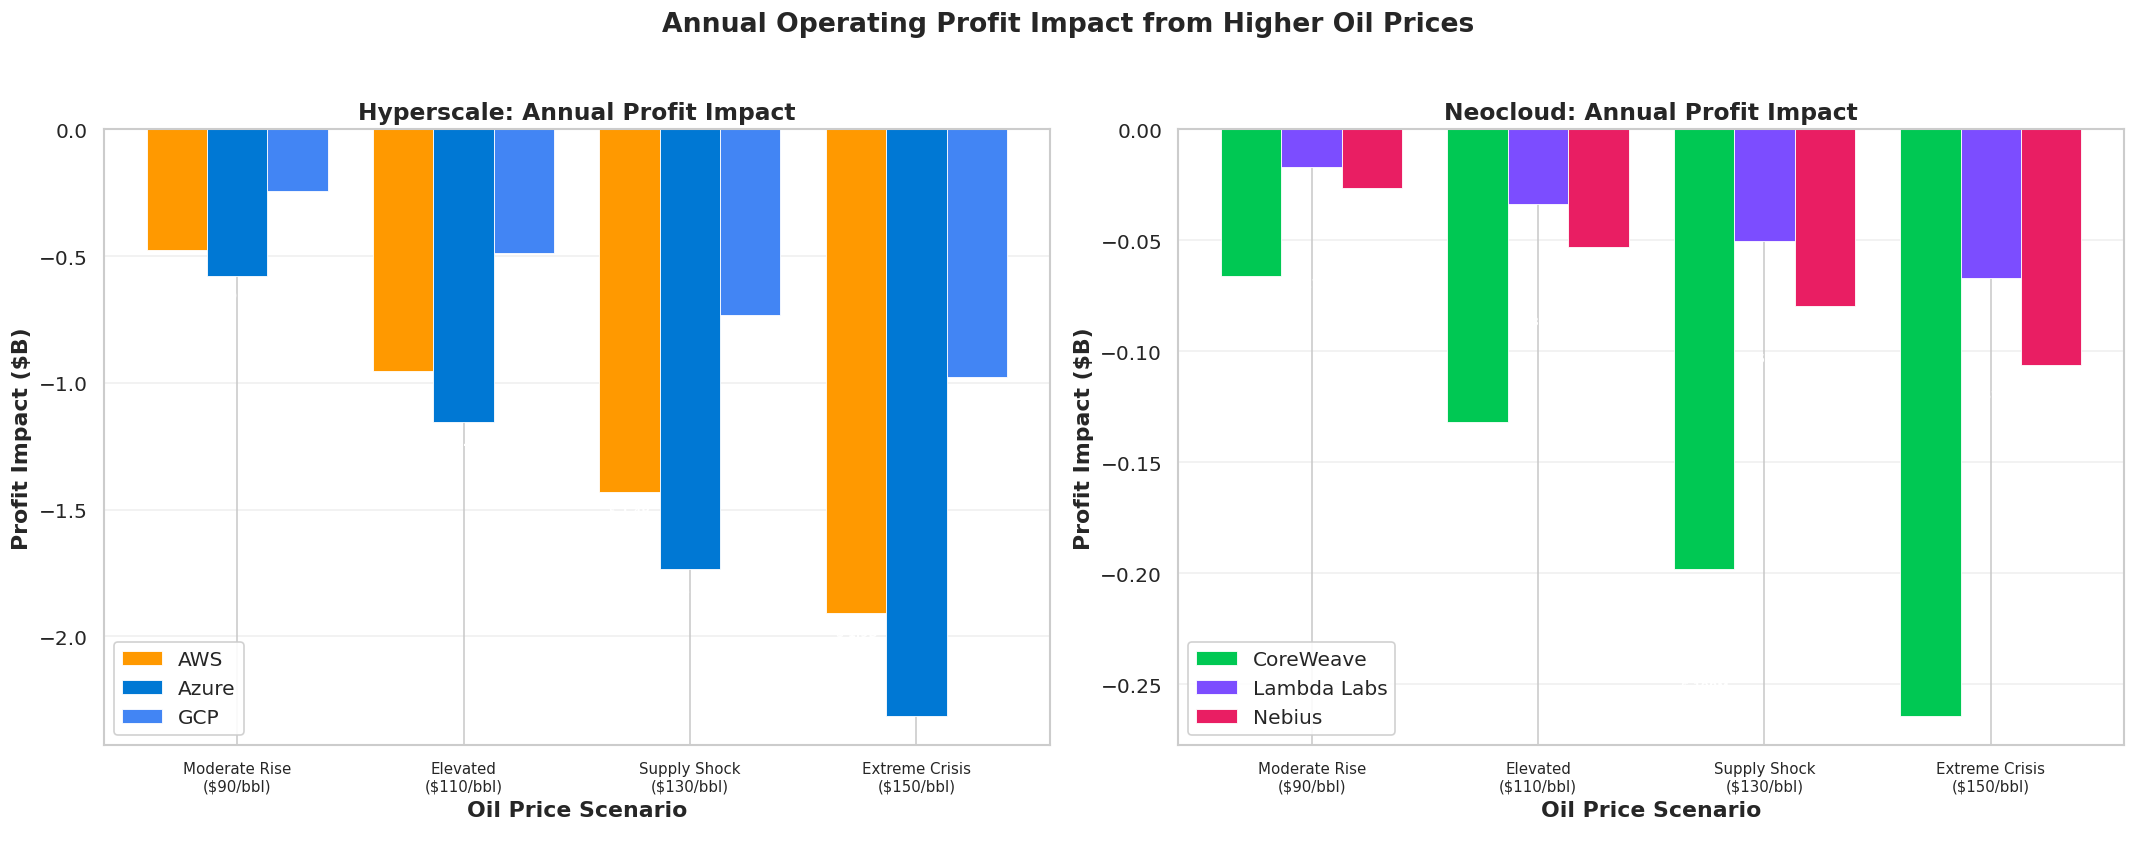

In [8]:
# Chart 3: Dollar Impact on Operating Profit
non_baseline = results_df[results_df['Scenario'] != 'Baseline'].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, vtype, title in zip(axes, ['Hyperscale', 'Neocloud'],
                             ['Hyperscale: Annual Profit Impact', 'Neocloud: Annual Profit Impact']):
    type_df = non_baseline[non_baseline['Type'] == vtype]
    vendor_names = type_df['Vendor'].unique()
    scenario_labels = [s for s in scenario_names if s != 'Baseline']
    n_vendors = len(vendor_names)
    x = np.arange(len(scenario_labels))
    width = 0.8 / n_vendors

    for i, vendor in enumerate(vendor_names):
        vdata = type_df[type_df['Vendor'] == vendor]
        impacts = [vdata[vdata['Scenario'] == s]['Profit Impact ($B)'].values[0] for s in scenario_labels]
        color = vendors[vendor]['color']
        bars = ax.bar(x + i * width - (n_vendors - 1) * width / 2, impacts,
                      width, label=vendor, color=color, edgecolor='white', linewidth=0.5)

        for bar, impact in zip(bars, impacts):
            if vtype == 'Hyperscale':
                label = f'${impact:.1f}B'
            else:
                label = f'${impact*1000:.0f}M'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05,
                    label, ha='center', va='top', fontsize=7, fontweight='bold', color='white')

    ax.set_xlabel('Oil Price Scenario', fontweight='bold')
    ylabel = 'Profit Impact ($B)' if vtype == 'Hyperscale' else 'Profit Impact ($B)'
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    oil_labels = ['$90/bbl', '$110/bbl', '$130/bbl', '$150/bbl']
    ax.set_xticklabels([f'{s}\n({o})' for s, o in zip(scenario_labels, oil_labels)],
                       rotation=0, ha='center', fontsize=9)
    ax.legend(loc='lower left', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

fig.suptitle('Annual Operating Profit Impact from Higher Oil Prices',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_profit_impact.png', bbox_inches='tight', dpi=150)
plt.show()

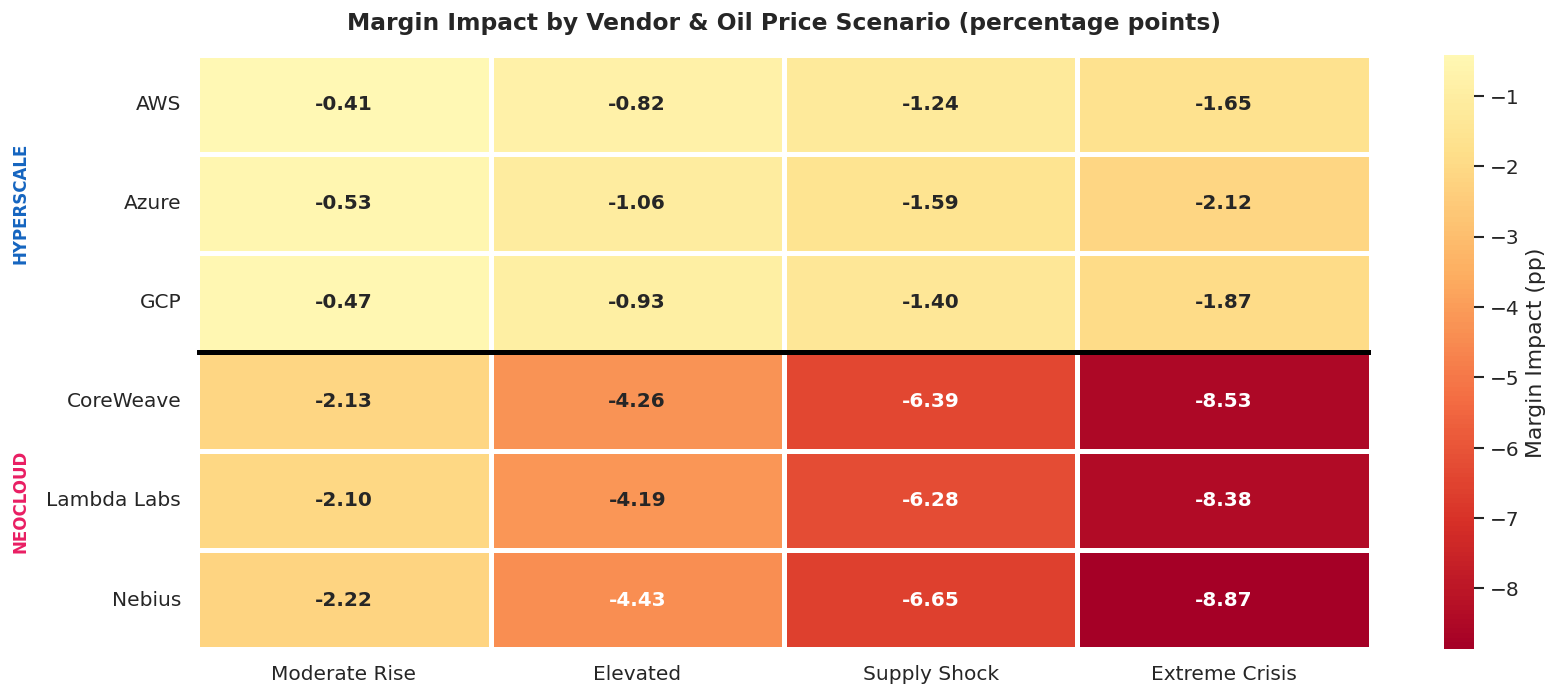

In [9]:
# Chart 4: Heatmap of Margin Impact (pp) by Vendor and Scenario
fig, ax = plt.subplots(figsize=(14, 6))

heatmap_data = results_df[results_df['Scenario'] != 'Baseline'].pivot_table(
    index='Vendor',
    columns='Scenario',
    values='Margin Impact (pp)',
    aggfunc='first'
)[['Moderate Rise', 'Elevated', 'Supply Shock', 'Extreme Crisis']]

# Sort by vendor type then by impact magnitude
vendor_order = ['AWS', 'Azure', 'GCP', 'CoreWeave', 'Lambda Labs', 'Nebius']
heatmap_data = heatmap_data.reindex(vendor_order)

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=2, linecolor='white', cbar_kws={'label': 'Margin Impact (pp)'},
            ax=ax, annot_kws={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('Margin Impact by Vendor & Oil Price Scenario (percentage points)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('')
ax.set_xlabel('')

# Add type labels
ax.axhline(y=3, color='black', linewidth=3)
ax.text(-0.6, 1.5, 'HYPERSCALE', rotation=90, va='center', ha='center',
        fontsize=10, fontweight='bold', color='#1565C0')
ax.text(-0.6, 4.5, 'NEOCLOUD', rotation=90, va='center', ha='center',
        fontsize=10, fontweight='bold', color='#E91E63')

plt.tight_layout()
plt.savefig('chart_heatmap_impact.png', bbox_inches='tight', dpi=150)
plt.show()

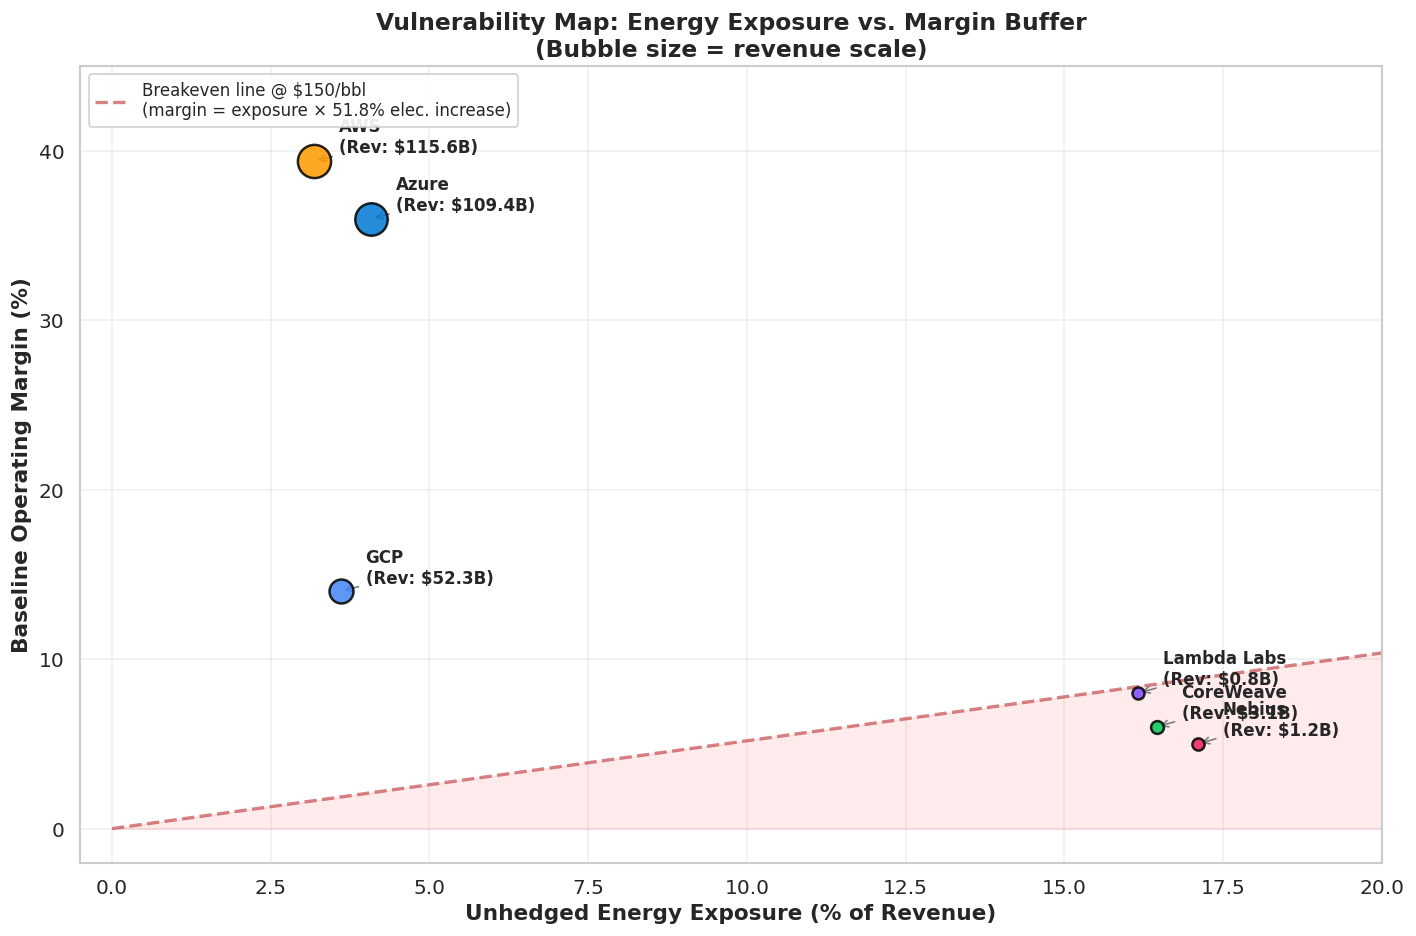

In [10]:
# Chart 5: Sensitivity Analysis — Energy Exposure vs Margin Buffer
fig, ax = plt.subplots(figsize=(12, 8))

for vendor_name, v in vendors.items():
    energy_exposure = v['energy_pct_of_revenue'] * (1 - v['ppa_hedge_pct']/100)
    margin = v['operating_margin_pct']
    margin_buffer_ratio = margin / energy_exposure if energy_exposure > 0 else float('inf')

    size = v['revenue_B'] * 3 + 50
    ax.scatter(energy_exposure, margin, s=size, c=v['color'],
              edgecolors='black', linewidth=1.5, zorder=5, alpha=0.85)
    ax.annotate(f'{vendor_name}\n(Rev: ${v["revenue_B"]:.1f}B)',
                (energy_exposure, margin),
                textcoords='offset points', xytext=(15, 5),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Breakeven line at $150/bbl scenario
extreme_elec_change = scenarios[scenarios['Scenario'] == 'Extreme Crisis']['Electricity Price Change (%)'].values[0] / 100
x_range = np.linspace(0, 20, 100)
breakeven_margin = x_range * extreme_elec_change
ax.plot(x_range, breakeven_margin, 'r--', linewidth=2, alpha=0.7,
        label=f'Breakeven line @ $150/bbl\n(margin = exposure × {extreme_elec_change:.1%} elec. increase)')
ax.fill_between(x_range, 0, breakeven_margin, alpha=0.08, color='red')

ax.set_xlabel('Unhedged Energy Exposure (% of Revenue)', fontsize=13, fontweight='bold')
ax.set_ylabel('Baseline Operating Margin (%)', fontsize=13, fontweight='bold')
ax.set_title('Vulnerability Map: Energy Exposure vs. Margin Buffer\n'
             '(Bubble size = revenue scale)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 20)
ax.set_ylim(-2, 45)

plt.tight_layout()
plt.savefig('chart_vulnerability_map.png', bbox_inches='tight', dpi=150)
plt.show()

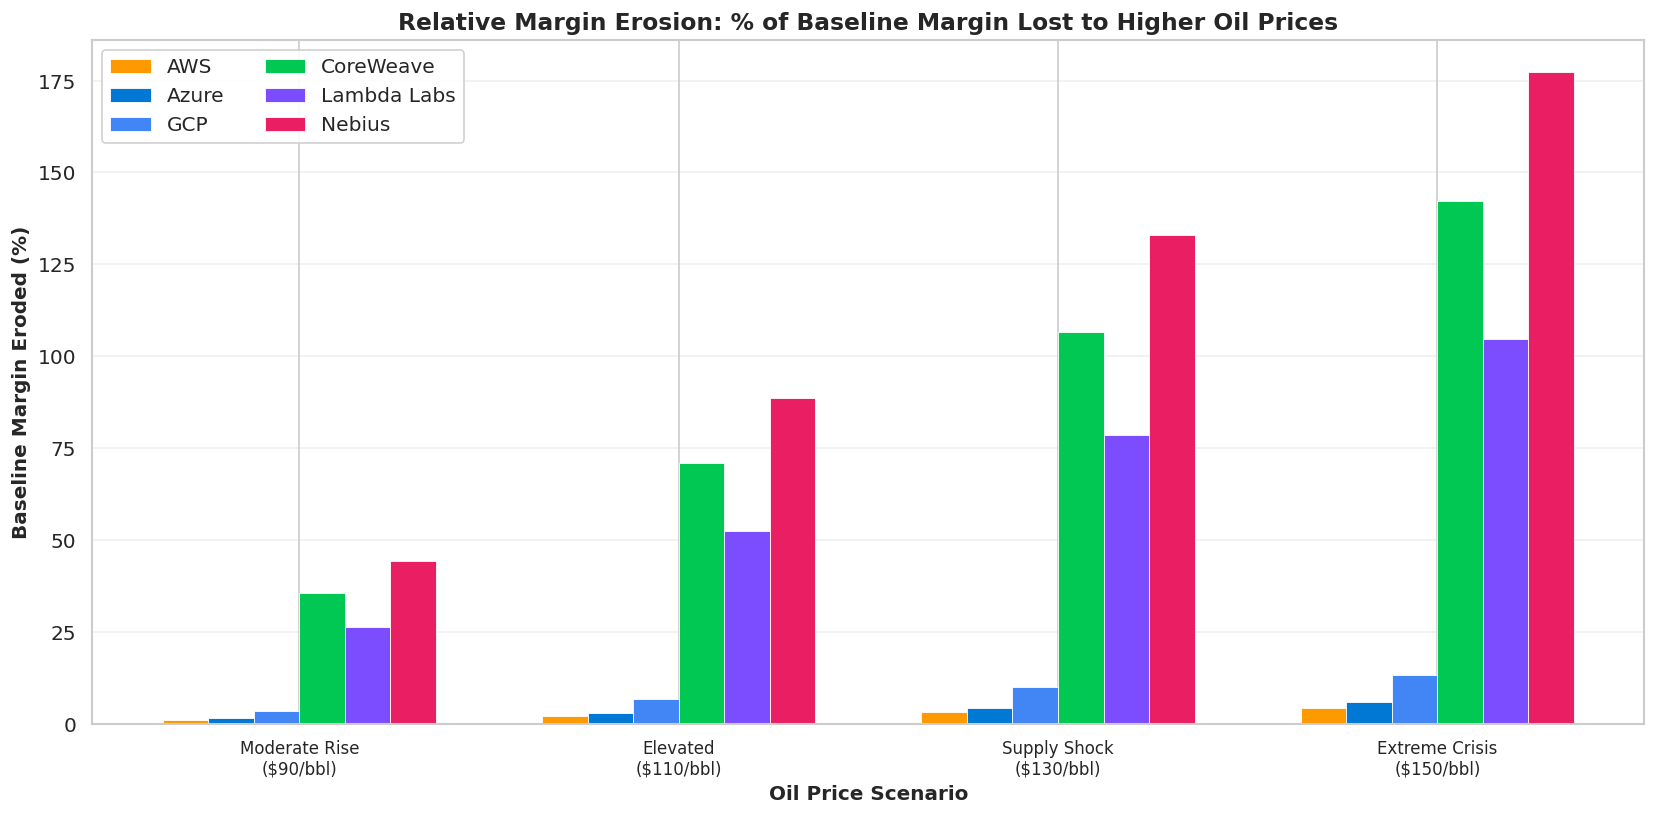

In [11]:
# Chart 6: Relative Margin Erosion (% of baseline margin lost)
fig, ax = plt.subplots(figsize=(14, 7))

non_baseline_pct = results_df[results_df['Scenario'] != 'Baseline'].copy()
non_baseline_pct['Margin Eroded (%)'] = -non_baseline_pct['Margin Change (%)']

scenario_labels = ['Moderate Rise', 'Elevated', 'Supply Shock', 'Extreme Crisis']
x = np.arange(len(scenario_labels))
width = 0.12

all_vendors = ['AWS', 'Azure', 'GCP', 'CoreWeave', 'Lambda Labs', 'Nebius']

for i, vendor in enumerate(all_vendors):
    vdata = non_baseline_pct[non_baseline_pct['Vendor'] == vendor]
    erosion = [vdata[vdata['Scenario'] == s]['Margin Eroded (%)'].values[0] for s in scenario_labels]
    color = vendors[vendor]['color']
    bars = ax.bar(x + i * width - (len(all_vendors) - 1) * width / 2, erosion,
                  width, label=vendor, color=color, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Oil Price Scenario', fontsize=12, fontweight='bold')
ax.set_ylabel('Baseline Margin Eroded (%)', fontsize=12, fontweight='bold')
ax.set_title('Relative Margin Erosion: % of Baseline Margin Lost to Higher Oil Prices',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
oil_labels = ['$90/bbl', '$110/bbl', '$130/bbl', '$150/bbl']
ax.set_xticklabels([f'{s}\n({o})' for s, o in zip(scenario_labels, oil_labels)], fontsize=10)
ax.legend(loc='upper left', ncol=2, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_relative_erosion.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Summary Tables

In [12]:
# Final summary: side-by-side comparison
print("\n" + "="*120)
print("EXECUTIVE SUMMARY: MARGIN IMPACT BY OIL PRICE SCENARIO")
print("="*120)

for vtype in ['Hyperscale', 'Neocloud']:
    print(f"\n{'━'*120}")
    print(f"  {vtype.upper()} VENDORS")
    print(f"{'━'*120}")

    type_results = results_df[results_df['Type'] == vtype]

    summary_rows = []
    for vendor in type_results['Vendor'].unique():
        v_data = type_results[type_results['Vendor'] == vendor]
        row = {'Vendor': vendor}
        row['Revenue ($B)'] = vendors[vendor]['revenue_B']
        row['Baseline Margin'] = f"{vendors[vendor]['operating_margin_pct']:.1f}%"
        row['Energy/Rev'] = f"{vendors[vendor]['energy_pct_of_revenue']:.1f}%"
        row['Hedged'] = f"{vendors[vendor]['ppa_hedge_pct']}%"

        for scenario in scenario_names[1:]:
            s_data = v_data[v_data['Scenario'] == scenario]
            margin = s_data['New Margin (%)'].values[0]
            impact = s_data['Margin Impact (pp)'].values[0]
            row[f'{scenario}'] = f"{margin:.1f}% ({impact:+.2f}pp)"

        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))

# Aggregate comparison
print(f"\n\n{'='*120}")
print("AGGREGATE COMPARISON: HYPERSCALE vs. NEOCLOUD")
print(f"{'='*120}")

agg_rows = []
for vtype in ['Hyperscale', 'Neocloud']:
    type_data = results_df[results_df['Type'] == vtype]
    row = {'Segment': vtype}

    baseline = type_data[type_data['Scenario'] == 'Baseline']['Baseline Margin (%)'].mean()
    row['Avg Baseline Margin'] = f"{baseline:.1f}%"

    for scenario in scenario_names[1:]:
        s_data = type_data[type_data['Scenario'] == scenario]
        avg_new = s_data['New Margin (%)'].mean()
        avg_impact = s_data['Margin Impact (pp)'].mean()
        total_profit_hit = s_data['Profit Impact ($B)'].sum()
        row[f'{scenario} Margin'] = f"{avg_new:.1f}% ({avg_impact:+.2f}pp)"
        row[f'{scenario} $ Hit'] = f"${total_profit_hit:.2f}B"

    agg_rows.append(row)

agg_df = pd.DataFrame(agg_rows)
print(agg_df.to_string(index=False))


EXECUTIVE SUMMARY: MARGIN IMPACT BY OIL PRICE SCENARIO

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HYPERSCALE VENDORS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Vendor  Revenue ($B) Baseline Margin Energy/Rev Hedged   Moderate Rise        Elevated    Supply Shock  Extreme Crisis
   AWS         115.6           39.4%       9.1%    65% 39.0% (-0.41pp) 38.6% (-0.82pp) 38.2% (-1.24pp) 37.7% (-1.65pp)
 Azure         109.4           36.0%      10.2%    60% 35.5% (-0.53pp) 34.9% (-1.06pp) 34.4% (-1.59pp) 33.9% (-2.12pp)
   GCP          52.3           14.0%      12.0%    70% 13.5% (-0.47pp) 13.1% (-0.93pp) 12.6% (-1.40pp) 12.1% (-1.87pp)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NEOCLOUD VENDORS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [13]:
# Key risk metrics table
print("\n" + "="*100)
print("KEY RISK METRICS")
print("="*100)

risk_rows = []
for vendor_name, v in vendors.items():
    energy_exposure = v['energy_pct_of_revenue'] * (1 - v['ppa_hedge_pct']/100)
    margin = v['operating_margin_pct']

    # Oil price that would wipe out all margin
    if energy_exposure > 0:
        max_elec_increase = margin / energy_exposure
        # Reverse the transmission: elec_change = oil_change * passthrough_chain
        full_passthrough = OIL_TO_GAS_PASSTHROUGH * GAS_TO_ELECTRICITY_PASSTHROUGH
        oil_change_to_zero = max_elec_increase / full_passthrough
        oil_price_to_zero = 70 * (1 + oil_change_to_zero)
    else:
        oil_price_to_zero = float('inf')

    # Impact at $150 (Extreme Crisis)
    extreme = results_df[(results_df['Vendor'] == vendor_name) &
                          (results_df['Scenario'] == 'Extreme Crisis')]

    risk_rows.append({
        'Vendor': vendor_name,
        'Type': v['type'],
        'Unhedged Energy Exposure (% Rev)': f"{energy_exposure:.1f}%",
        'Baseline Margin': f"{margin:.1f}%",
        'Margin @ $150/bbl': f"{extreme['New Margin (%)'].values[0]:.1f}%",
        'Oil Price to Zero Margin': f"${oil_price_to_zero:.0f}/bbl" if oil_price_to_zero < 10000 else 'N/A',
        'Margin Safety Ratio': f"{margin / energy_exposure:.1f}x" if energy_exposure > 0 else 'N/A'
    })

risk_df = pd.DataFrame(risk_rows)
print(risk_df.to_string(index=False))

print("\n")
print("Margin Safety Ratio = Baseline Margin / Unhedged Energy Exposure")
print("  Higher ratio → more resilient to energy price shocks")
print("  <1.0x → vendor goes negative margin before energy costs double")


KEY RISK METRICS
     Vendor       Type Unhedged Energy Exposure (% Rev) Baseline Margin Margin @ $150/bbl Oil Price to Zero Margin Margin Safety Ratio
        AWS Hyperscale                             3.2%           39.4%             37.7%                $1979/bbl               12.4x
      Azure Hyperscale                             4.1%           36.0%             33.9%                $1432/bbl                8.8x
        GCP Hyperscale                             3.6%           14.0%             12.1%                 $670/bbl                3.9x
  CoreWeave   Neocloud                            16.4%            6.0%             -2.5%                 $126/bbl                0.4x
Lambda Labs   Neocloud                            16.2%            8.0%             -0.4%                 $146/bbl                0.5x
     Nebius   Neocloud                            17.1%            5.0%             -3.9%                 $115/bbl                0.3x


Margin Safety Ratio = Baseline Marg

## 6. Key Findings & Conclusions

### Transmission Mechanism
- Every **$20/bbl increase** in oil prices translates to approximately a **13% rise in natural gas** prices and a **7-8% increase in electricity** costs (for unhedged exposure)
- The impact is **non-linear in effect** — neoclouds with thin margins face existential risk at extreme oil prices, while hyperscalers absorb the shock

### Hyperscale Vendors (AWS, Azure, GCP)
- **Well-insulated**: High margins (14-39%) provide a substantial buffer
- **Hedging advantage**: 60-70% of energy costs are covered by long-term PPAs and renewable contracts
- Even in the **Extreme Crisis** ($150/bbl) scenario, average margins decline only ~3-4 percentage points
- AWS is best-positioned with highest margin (39.4%) and strong hedging (65%)
- GCP is most vulnerable among hyperscalers due to its lower margin (14%)

### Neocloud Vendors (CoreWeave, Lambda Labs, Nebius)
- **Highly vulnerable**: Thin margins (5-8%) leave almost no buffer
- **Limited hedging**: Only 20-30% of energy costs are protected
- Energy represents 20-24% of revenue vs. 9-12% for hyperscalers
- In the **Supply Shock** ($130/bbl) scenario, neocloud margins compress to near-zero or negative territory
- At **$150/bbl**, neoclouds face potential operating losses, threatening viability without price increases

### Strategic Implications
1. **Neocloud pricing power**: Can neoclouds pass through energy costs? In a competitive market with hyperscaler alternatives, this is challenging
2. **PPA strategy is critical**: The gap in hedging (60-70% vs 20-30%) is a structural disadvantage for neoclouds
3. **Capex timing risk**: Neoclouds investing $30-35B in 2026 capex face amplified risk if oil shocks coincide with capacity buildout
4. **Hyperscaler moat deepens**: Energy cost advantages compound the existing scale advantages, potentially accelerating neocloud consolidation in a high-oil-price environment